# Spam Dataset Exploration

Week 1 focuses on loading the raw Kaggle CSV, checking its basic structure, and preparing it for text preprocessing.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
WEEK1_ROOT = PROJECT_ROOT / 'week-1'
sys.path.insert(0, str(WEEK1_ROOT))
from src.preprocess import remove_nulls_and_duplicates, resolve_columns  # type: ignore[reportMissingImports]

DATA_PATH = WEEK1_ROOT / 'data' / 'spam_raw.csv'
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded dataset: {DATA_PATH}')
else:
    df = pd.DataFrame([
        ('ham', 'Project meeting is scheduled tomorrow'),
        ('ham', 'Please send the report this afternoon'),
        ('ham', 'Can you share the class notes'),
        ('ham', 'Thanks for sending the document'),
        ('ham', 'See you at the office tomorrow'),
        ('spam', 'Win a free cash prize claim now'),
        ('spam', 'Urgent reward selected click link'),
        ('spam', 'Congratulations receive bonus money today'),
        ('spam', 'Exclusive offer reply to win'),
        ('spam', 'You have won a shopping voucher'),
    ], columns=['label', 'message'])
    print('WARNING: week-1/data/spam_raw.csv is missing; using embedded demo data.')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

In [2]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.info()

Shape: (10, 2)
Columns: ['label', 'message']
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    10 non-null     str  
 1   message  10 non-null     str  
dtypes: str(2)
memory usage: 292.0 bytes


In [3]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.info())

Shape: (10, 2)
Columns: ['label', 'message']
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    10 non-null     str  
 1   message  10 non-null     str  
dtypes: str(2)
memory usage: 292.0 bytes


None

In [4]:
print('Null counts:')
display(df.isnull().sum())

print('Duplicate rows:', df.duplicated().sum())

Null counts:


label      0
message    0
dtype: int64

Duplicate rows: 0


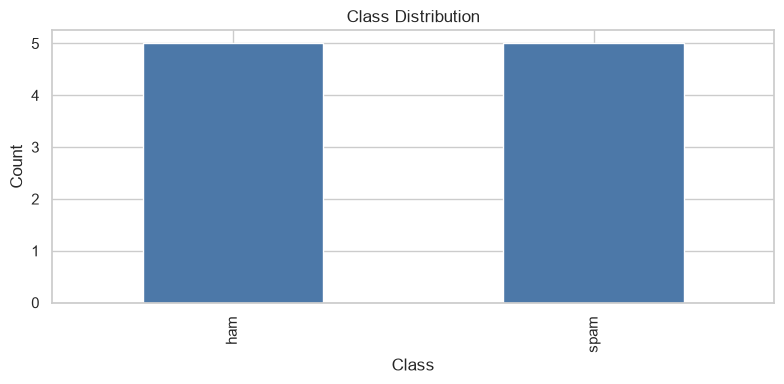

In [5]:
label_col, text_col = resolve_columns(df)
class_counts = df[label_col].astype(str).str.strip().str.lower().value_counts()

ax = class_counts.plot(kind='bar', color='#4C78A8')
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
sample_rows = df[[label_col, text_col]].head(5)
display(sample_rows)

,label,message
0,ham,Project meeting is scheduled tomorrow
1,ham,Please send the report this afternoon
2,ham,Can you share the class notes
3,ham,Thanks for sending the document
4,ham,See you at the office tomorrow


In [7]:
cleaned_preview = remove_nulls_and_duplicates(df, label_col=label_col, text_col=text_col)
print('After removing nulls and duplicates:', cleaned_preview.shape)
display(cleaned_preview.head())

After removing nulls and duplicates: (10, 2)


,label,message
0,ham,Project meeting is scheduled tomorrow
1,ham,Please send the report this afternoon
2,ham,Can you share the class notes
3,ham,Thanks for sending the document
4,ham,See you at the office tomorrow


## Week 2

Feature extraction and model training will be added in the next phase.